In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [2]:
columns = [
    "class", "cap-shape", "cap-surface", "cap-color", "bruises",
    "odor", "gill-attachment", "gill-spacing", "gill-size", "gill-color",
    "stalk-shape", "stalk-root", "stalk-surface-above-ring",
    "stalk-surface-below-ring", "stalk-color-above-ring",
    "stalk-color-below-ring", "veil-type", "veil-color",
    "ring-number", "ring-type", "spore-print-color",
    "population", "habitat"
]

In [3]:
m = pd.read_csv(
    r"C:\Users\Maharshi Goswami\OneDrive\Documents\ML\Module 4\expanded\expanded.data",
    sep=',',
    header=None
)

print(m.shape)
print(m.head())

(8417, 23)
       0       1       2      3        4       5     6        7       8   \
0  EDIBLE  CONVEX  SMOOTH  WHITE  BRUISES  ALMOND  FREE  CROWDED  NARROW   
1  EDIBLE  CONVEX  SMOOTH  WHITE  BRUISES  ALMOND  FREE  CROWDED  NARROW   
2  EDIBLE  CONVEX  SMOOTH  WHITE  BRUISES  ALMOND  FREE  CROWDED  NARROW   
3  EDIBLE  CONVEX  SMOOTH  WHITE  BRUISES  ALMOND  FREE  CROWDED  NARROW   
4  EDIBLE  CONVEX  SMOOTH  WHITE  BRUISES  ALMOND  FREE  CROWDED  NARROW   

      9   ...      13     14     15       16     17   18       19      20  \
0  WHITE  ...  SMOOTH  WHITE  WHITE  PARTIAL  WHITE  ONE  PENDANT  PURPLE   
1  WHITE  ...  SMOOTH  WHITE  WHITE  PARTIAL  WHITE  ONE  PENDANT   BROWN   
2   PINK  ...  SMOOTH  WHITE  WHITE  PARTIAL  WHITE  ONE  PENDANT  PURPLE   
3   PINK  ...  SMOOTH  WHITE  WHITE  PARTIAL  WHITE  ONE  PENDANT   BROWN   
4  BROWN  ...  SMOOTH  WHITE  WHITE  PARTIAL  WHITE  ONE  PENDANT  PURPLE   

        21     22  
0  SEVERAL  WOODS  
1  SEVERAL  WOODS  
2  SEVERA

In [4]:
m.columns = columns

In [5]:
m.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,EDIBLE,CONVEX,SMOOTH,WHITE,BRUISES,ALMOND,FREE,CROWDED,NARROW,WHITE,...,SMOOTH,WHITE,WHITE,PARTIAL,WHITE,ONE,PENDANT,PURPLE,SEVERAL,WOODS
1,EDIBLE,CONVEX,SMOOTH,WHITE,BRUISES,ALMOND,FREE,CROWDED,NARROW,WHITE,...,SMOOTH,WHITE,WHITE,PARTIAL,WHITE,ONE,PENDANT,BROWN,SEVERAL,WOODS
2,EDIBLE,CONVEX,SMOOTH,WHITE,BRUISES,ALMOND,FREE,CROWDED,NARROW,PINK,...,SMOOTH,WHITE,WHITE,PARTIAL,WHITE,ONE,PENDANT,PURPLE,SEVERAL,WOODS
3,EDIBLE,CONVEX,SMOOTH,WHITE,BRUISES,ALMOND,FREE,CROWDED,NARROW,PINK,...,SMOOTH,WHITE,WHITE,PARTIAL,WHITE,ONE,PENDANT,BROWN,SEVERAL,WOODS
4,EDIBLE,CONVEX,SMOOTH,WHITE,BRUISES,ALMOND,FREE,CROWDED,NARROW,BROWN,...,SMOOTH,WHITE,WHITE,PARTIAL,WHITE,ONE,PENDANT,PURPLE,SEVERAL,WOODS


In [26]:
m.to_csv("mushroom_cleaned.csv", index=False)

In [7]:
import os
print(os.getcwd())

C:\Users\Maharshi Goswami\Documents\ML


In [6]:
m.shape

(8417, 23)

In [7]:
m.isnull().sum()

class                       0
cap-shape                   1
cap-surface                 1
cap-color                   1
bruises                     1
odor                        1
gill-attachment             1
gill-spacing                1
gill-size                   1
gill-color                  1
stalk-shape                 1
stalk-root                  1
stalk-surface-above-ring    1
stalk-surface-below-ring    1
stalk-color-above-ring      1
stalk-color-below-ring      1
veil-type                   1
veil-color                  1
ring-number                 1
ring-type                   1
spore-print-color           1
population                  1
habitat                     1
dtype: int64

In [8]:
m = m.fillna(m[columns].mode().iloc[0])

# My Target

In [9]:
m["class"].unique()

array(['EDIBLE', 'POISONOUS',
       '----------------------------------------------------------------------'],
      dtype=object)

In [10]:
m["class"]=m["class"].map({'EDIBLE':1 , 'POISONOUS':0})

# Encoding Features

In [11]:
m = pd.get_dummies(m, drop_first=True)

In [12]:
m.head()

,class,cap-shape_CONICAL,cap-shape_CONVEX,cap-shape_FLAT,cap-shape_KNOBBED,cap-shape_SUNKEN,cap-surface_GROOVES,cap-surface_SCALY,cap-surface_SMOOTH,cap-color_BUFF,...,population_NUMEROUS,population_SCATTERED,population_SEVERAL,population_SOLITARY,habitat_LEAVES,habitat_MEADOWS,habitat_PATHS,habitat_URBAN,habitat_WASTE,habitat_WOODS
0,1.0,False,True,False,False,False,False,False,True,False,...,False,False,True,False,False,False,False,False,False,True
1,1.0,False,True,False,False,False,False,False,True,False,...,False,False,True,False,False,False,False,False,False,True
2,1.0,False,True,False,False,False,False,False,True,False,...,False,False,True,False,False,False,False,False,False,True
3,1.0,False,True,False,False,False,False,False,True,False,...,False,False,True,False,False,False,False,False,False,True
4,1.0,False,True,False,False,False,False,False,True,False,...,False,False,True,False,False,False,False,False,False,True


In [13]:
m = m.fillna(m.mode().iloc[0])

In [14]:
bo0l=m.select_dtypes(include=bool).columns
m=m.astype(int)

In [15]:
m.head()

,class,cap-shape_CONICAL,cap-shape_CONVEX,cap-shape_FLAT,cap-shape_KNOBBED,cap-shape_SUNKEN,cap-surface_GROOVES,cap-surface_SCALY,cap-surface_SMOOTH,cap-color_BUFF,...,population_NUMEROUS,population_SCATTERED,population_SEVERAL,population_SOLITARY,habitat_LEAVES,habitat_MEADOWS,habitat_PATHS,habitat_URBAN,habitat_WASTE,habitat_WOODS
0,1,0,1,0,0,0,0,0,1,0,...,0,0,1,0,0,0,0,0,0,1
1,1,0,1,0,0,0,0,0,1,0,...,0,0,1,0,0,0,0,0,0,1
2,1,0,1,0,0,0,0,0,1,0,...,0,0,1,0,0,0,0,0,0,1
3,1,0,1,0,0,0,0,0,1,0,...,0,0,1,0,0,0,0,0,0,1
4,1,0,1,0,0,0,0,0,1,0,...,0,0,1,0,0,0,0,0,0,1


In [16]:
m.shape

(8417, 96)

In [17]:
x=m.drop("class",axis=1) 
y=m["class"]
X_train,X_test,Y_train,Y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [18]:
from sklearn.tree import DecisionTreeClassifier
DT = DecisionTreeClassifier(random_state=42)
DT.fit(X_train, Y_train)

DecisionTreeClassifier(random_state=42)

In [19]:
Y_pred=DT.predict(X_test)

In [20]:
acc = accuracy_score(Y_test, Y_pred)
print("Accuracy:", acc)

Accuracy: 1.0


# Classification Report

In [21]:
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       786
           1       1.00      1.00      1.00       898

    accuracy                           1.00      1684
   macro avg       1.00      1.00      1.00      1684
weighted avg       1.00      1.00      1.00      1684



In [67]:
cm = confusion_matrix(Y_test, Y_pred)
print(cm)

[[786   0]
 [  0 898]]


# Confusion Matrix

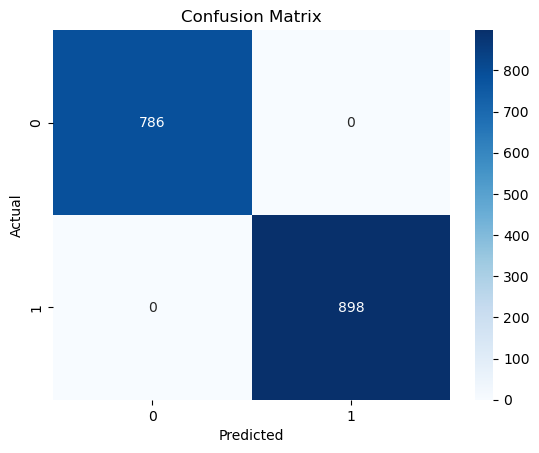

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Applying Hyper parameter tuning

In [75]:
from sklearn.metrics import accuracy_score

results = []

for depth in [3, 5, 10]:
    for split in [2, 5, 10]:
        for leaf in [1, 2, 4]:
            
            model = DecisionTreeClassifier(
                max_depth=depth,
                min_samples_split=split,
                min_samples_leaf=leaf,
                random_state=42
            )
            
            model.fit(X_train, Y_train)
            pred = model.predict(X_test)
            
            acc = accuracy_score(Y_test, pred)
            
            results.append((depth, split, leaf, acc))

In [76]:
for r in results:
    print(f"Depth={r[0]}, Split={r[1]}, Leaf={r[2]} → Accuracy={r[3]}")

Depth=3, Split=2, Leaf=1 → Accuracy=0.9845605700712589
Depth=3, Split=2, Leaf=2 → Accuracy=0.9845605700712589
Depth=3, Split=2, Leaf=4 → Accuracy=0.9845605700712589
Depth=3, Split=5, Leaf=1 → Accuracy=0.9845605700712589
Depth=3, Split=5, Leaf=2 → Accuracy=0.9845605700712589
Depth=3, Split=5, Leaf=4 → Accuracy=0.9845605700712589
Depth=3, Split=10, Leaf=1 → Accuracy=0.9845605700712589
Depth=3, Split=10, Leaf=2 → Accuracy=0.9845605700712589
Depth=3, Split=10, Leaf=4 → Accuracy=0.9845605700712589
Depth=5, Split=2, Leaf=1 → Accuracy=0.996437054631829
Depth=5, Split=2, Leaf=2 → Accuracy=0.996437054631829
Depth=5, Split=2, Leaf=4 → Accuracy=0.996437054631829
Depth=5, Split=5, Leaf=1 → Accuracy=0.996437054631829
Depth=5, Split=5, Leaf=2 → Accuracy=0.996437054631829
Depth=5, Split=5, Leaf=4 → Accuracy=0.996437054631829
Depth=5, Split=10, Leaf=1 → Accuracy=0.996437054631829
Depth=5, Split=10, Leaf=2 → Accuracy=0.996437054631829
Depth=5, Split=10, Leaf=4 → Accuracy=0.996437054631829
Depth=10, Spl

# FIINDING BEST RESULT

In [77]:
best = max(results, key=lambda x: x[3])
print("Best Params:", best)

Best Params: (10, 2, 1, 1.0)


# APPLYING CROSS VALIDATION

In [79]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(DT, x, y, cv=5)
print("Cross-validation scores:", scores)
print("Average Accuracy:", scores.mean())

Cross-validation scores: [0.46793349 1.         0.76232917 1.         0.61437908]
Average Accuracy: 0.7689283501495322
